In [ ]:
from google.colab import drive
import pandas as pd

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
def merge_data(image_dir , labels_dir):
 def get_filename_stem(filepath):
    # Extracts name without extension (e.g. '1_226.png' -> '1_226')
    return os.path.splitext(os.path.basename(filepath))[0]

# List actual files from mounted Google Drive
 image_files = [f for f in os.listdir(image_dir) ]
 label_files = [f for f in os.listdir(labels_dir) ]

# Map filename stems to full local paths
 image_map = {get_filename_stem(f): os.path.join(image_dir, f) for f in image_files}
 label_map = {get_filename_stem(f): os.path.join(labels_dir, f) for f in label_files}

# Match pairs
 matched_data = []
 for stem, img_path in image_map.items():
    if stem in label_map:
        matched_data.append({
            'file_id': stem,
            'image_path': img_path,
            'label_path': label_map[stem]
        })

 df = pd.DataFrame(matched_data)

 return df

In [ ]:
image_dir ="/content/drive/MyDrive/satalite data/data/images"
labels_dir ="/content/drive/MyDrive/satalite data/data/labels"

df=merge_data(image_dir , labels_dir)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   file_id     306 non-null    object
 1   image_path  306 non-null    object
 2   label_path  306 non-null    object
dtypes: object(3)
memory usage: 7.3+ KB


In [ ]:
file_path = '/content/drive/MyDrive/satalitedata.csv'

df.to_csv(file_path, index=False)

In [ ]:
import numpy as np
from PIL import Image

print(os.path.exists(df['label_path'].iloc[0]))
# Load the label mask
mask = Image.open(df['label_path'].iloc[0])
mask_array = np.array(mask)

# Print image properties
print("Mask shape:", mask_array.shape)
print("Unique pixel values:", np.unique(mask_array))

True
Mask shape: (128, 128)
Unique pixel values: [0 1]


In [ ]:
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt

def load_satellite_image(path):

    data = tiff.imread(path)

    #  (Height, Width, Channels)
    if data.ndim == 3 and data.shape[0] == 12:
        data = np.moveaxis(data, 0, -1)

    return data

def normalize_channel(band):
    
    p2, p98 = np.percentile(band, (2, 98)) #  clip to ignore extreme outliers/clouds
    if p98 == p2:
        return np.zeros_like(band, dtype=np.float32)
    clipped = np.clip(band, p2, p98)
    return (clipped - p2) / (p98 - p2)

In [ ]:
def visualize_all_channels(sat_data):
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()

    for ch_idx in range(12):
        band = sat_data[:, :, ch_idx]
        norm_band = normalize_channel(band)

        axes[ch_idx].imshow(norm_band, cmap='viridis')
        axes[ch_idx].set_title(f"Channel {ch_idx + 1}")
        axes[ch_idx].axis("off")

    plt.tight_layout()
    plt.show()

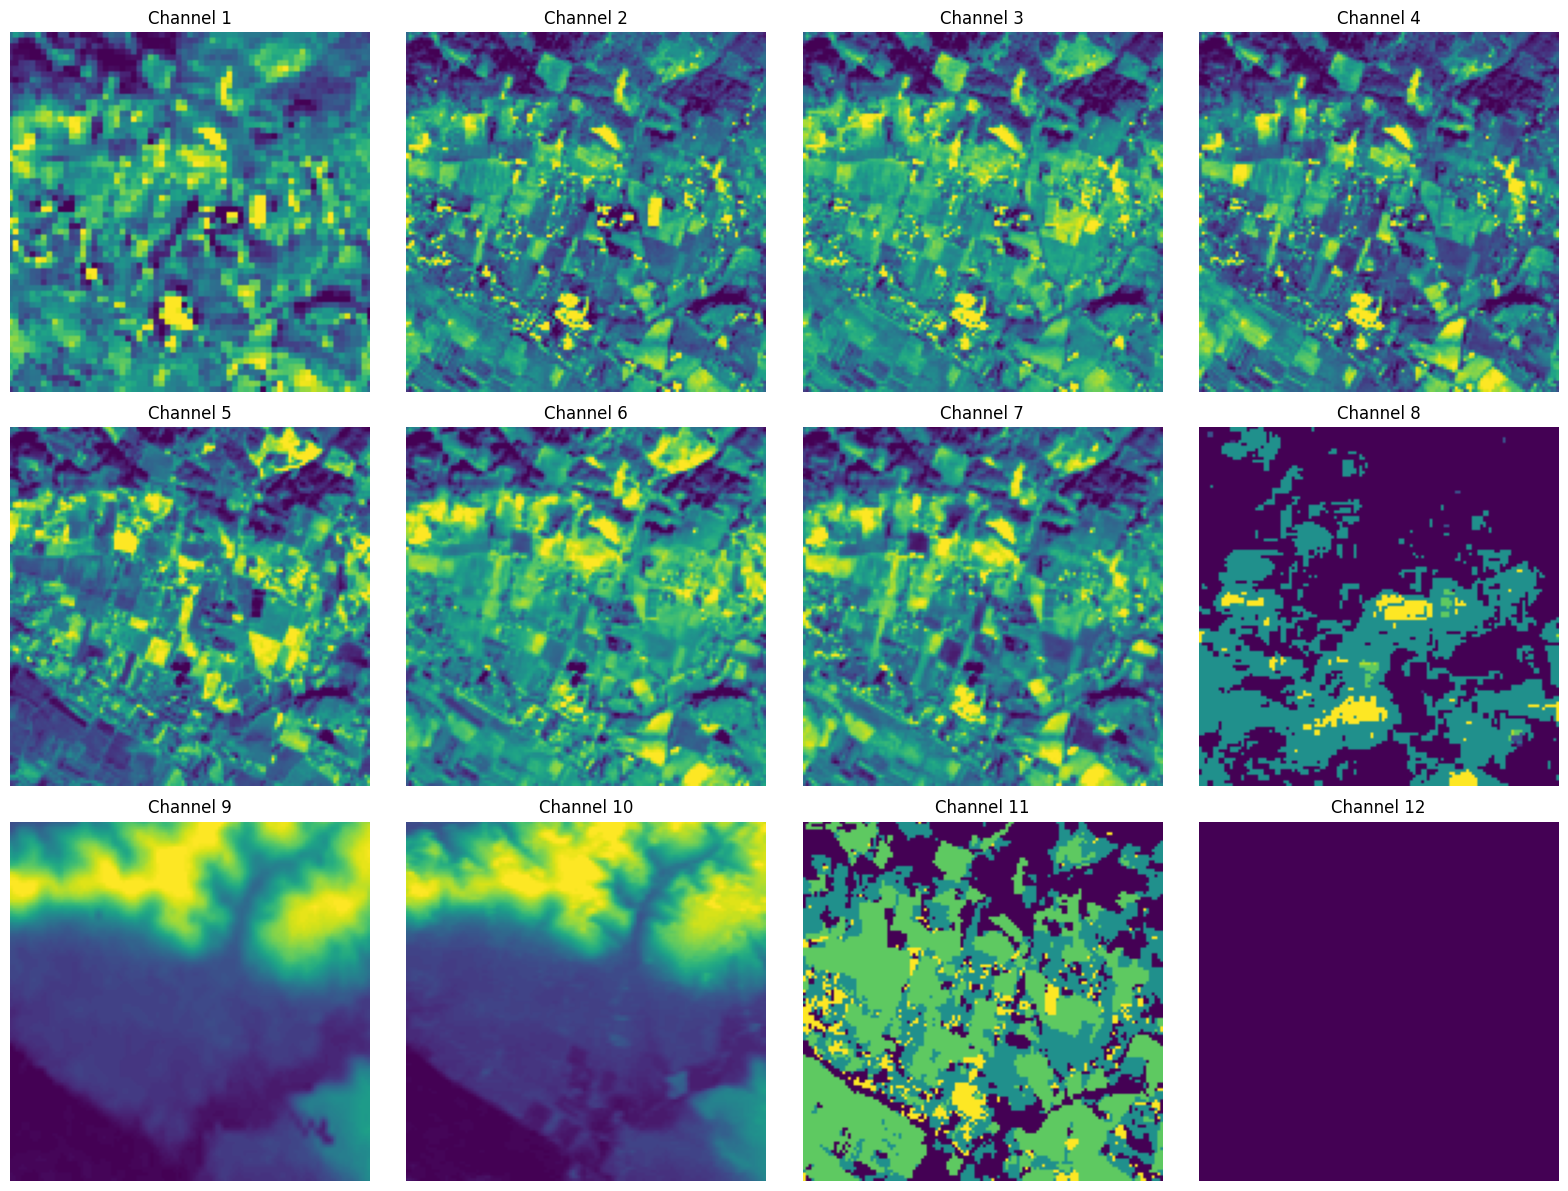

In [ ]:
sat_image = load_satellite_image(df['image_path'].iloc[0])
visualize_all_channels(sat_image)

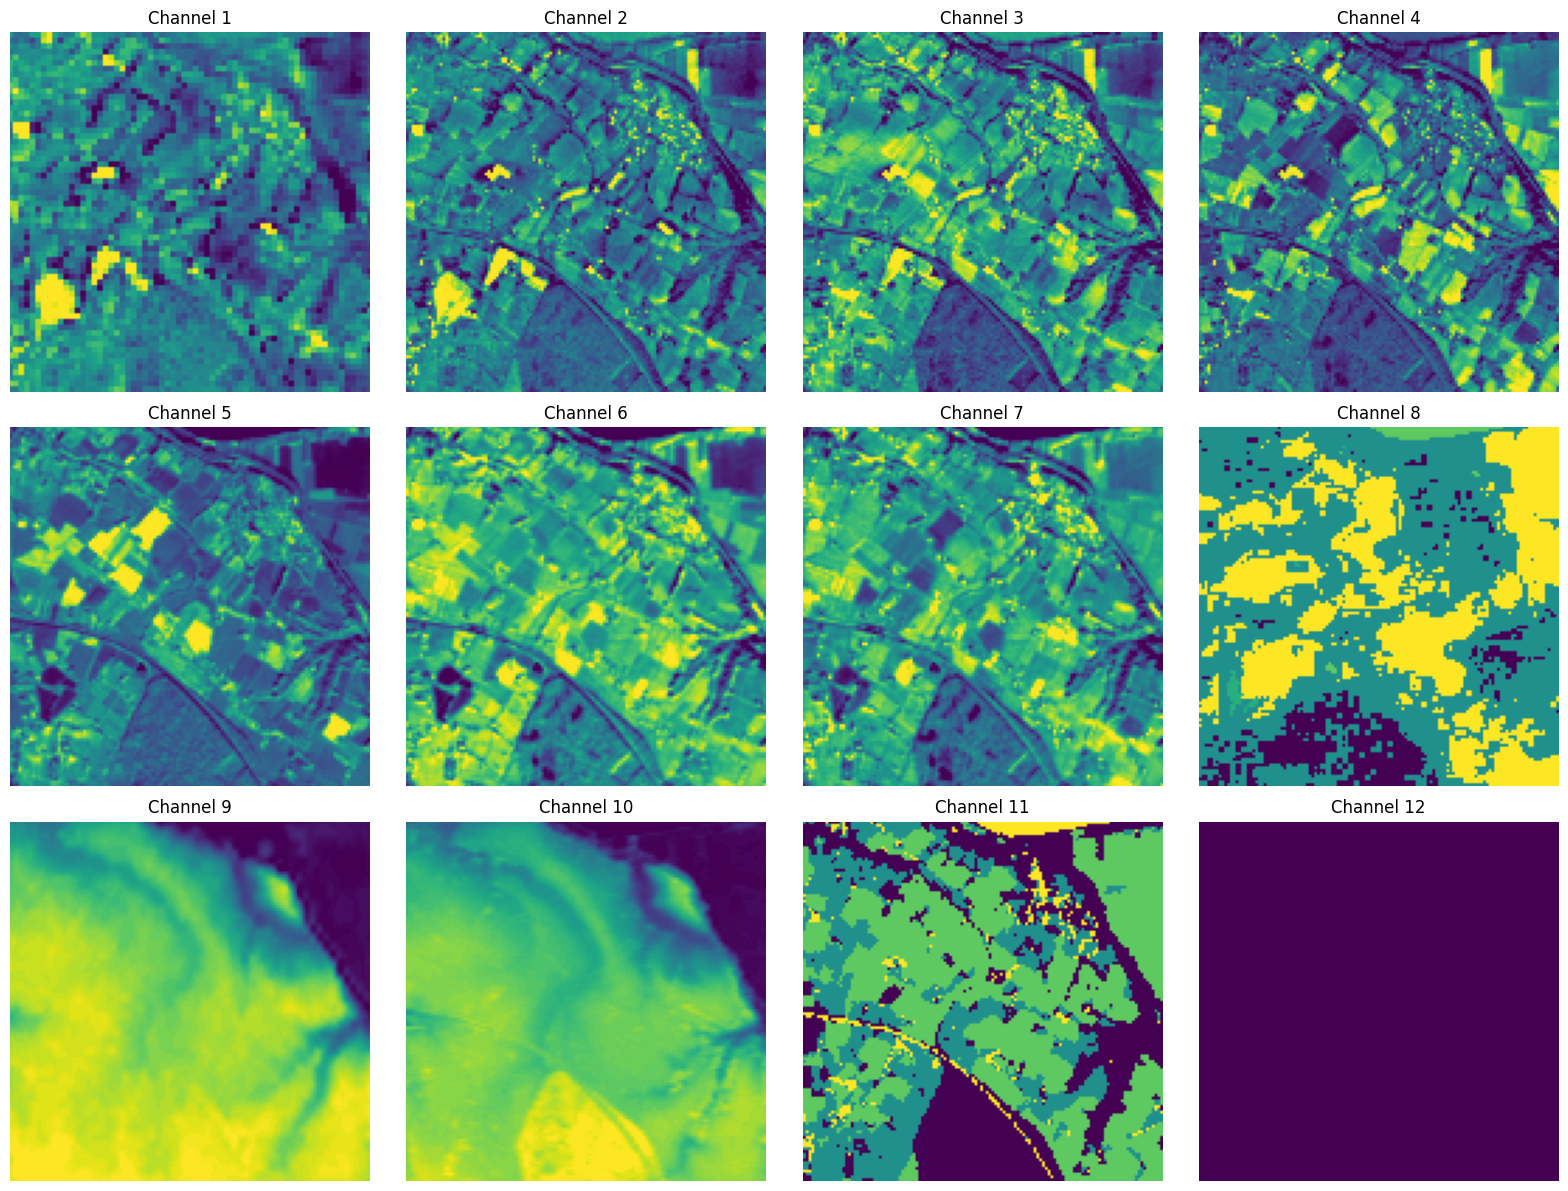

In [ ]:
sat_image = load_satellite_image(df['image_path'].iloc[35])
visualize_all_channels(sat_image)

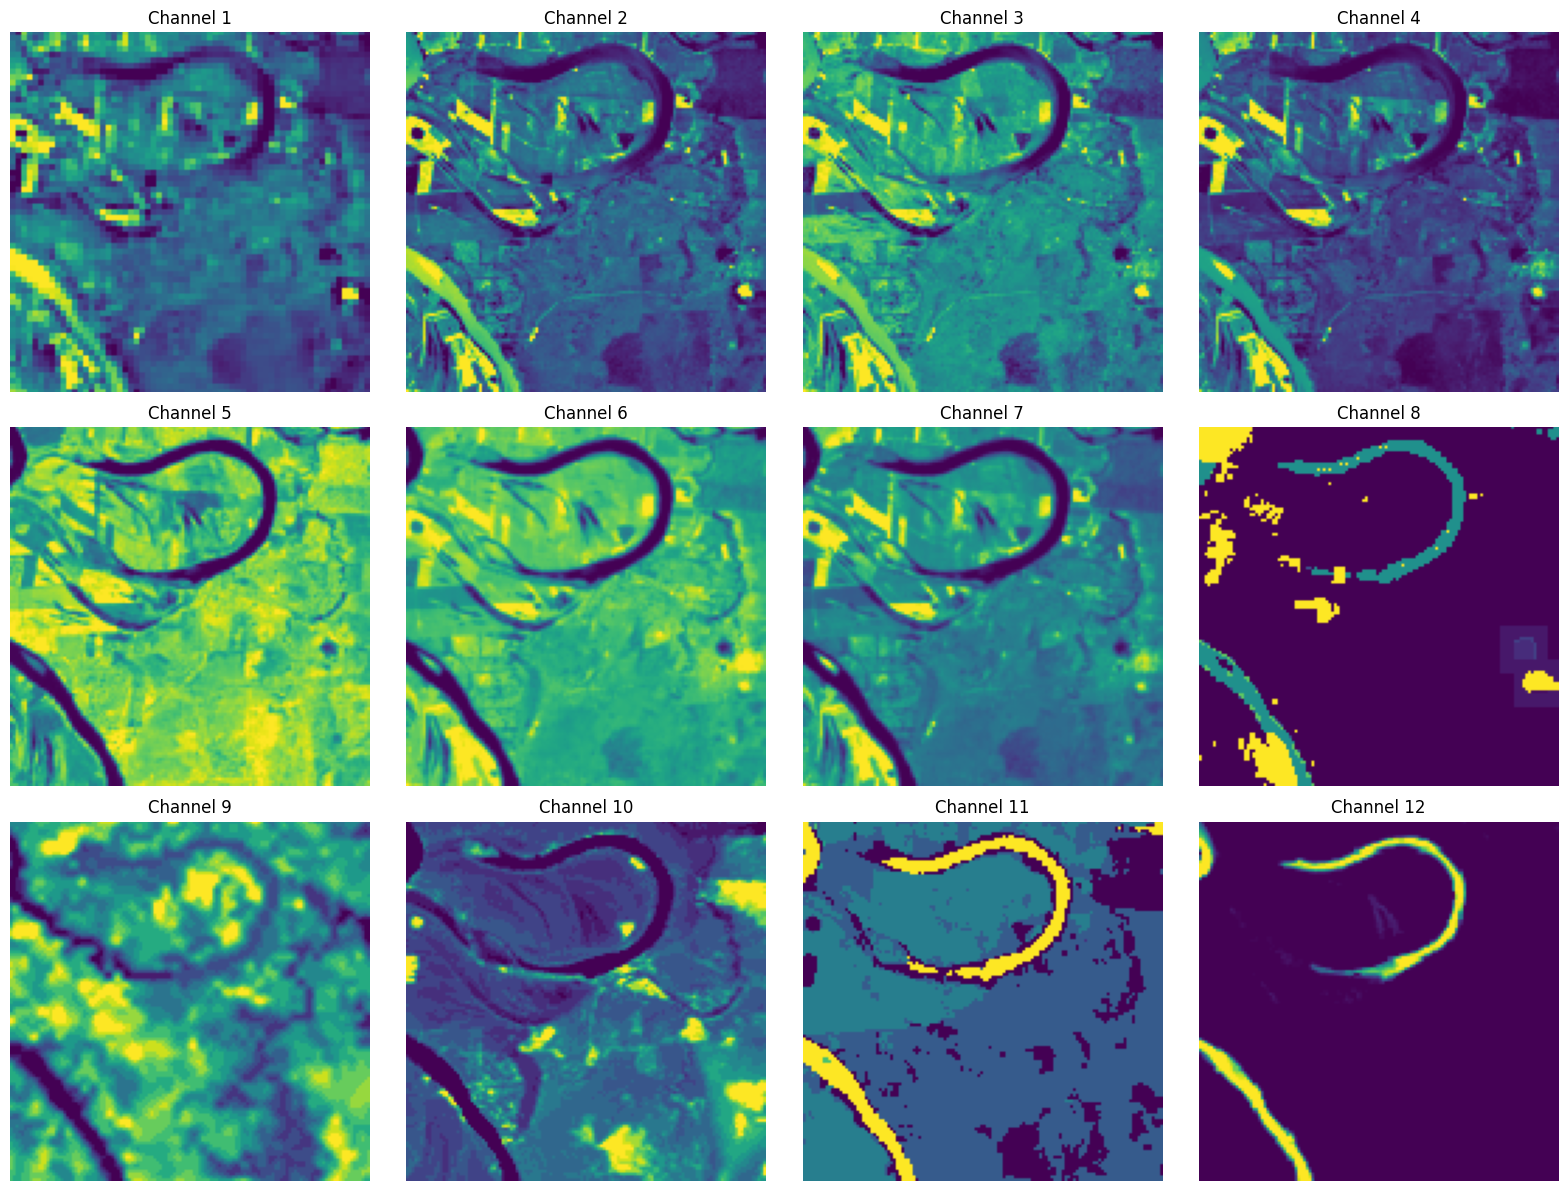

In [ ]:
sat_image = load_satellite_image(df['image_path'].iloc[100])
visualize_all_channels(sat_image)

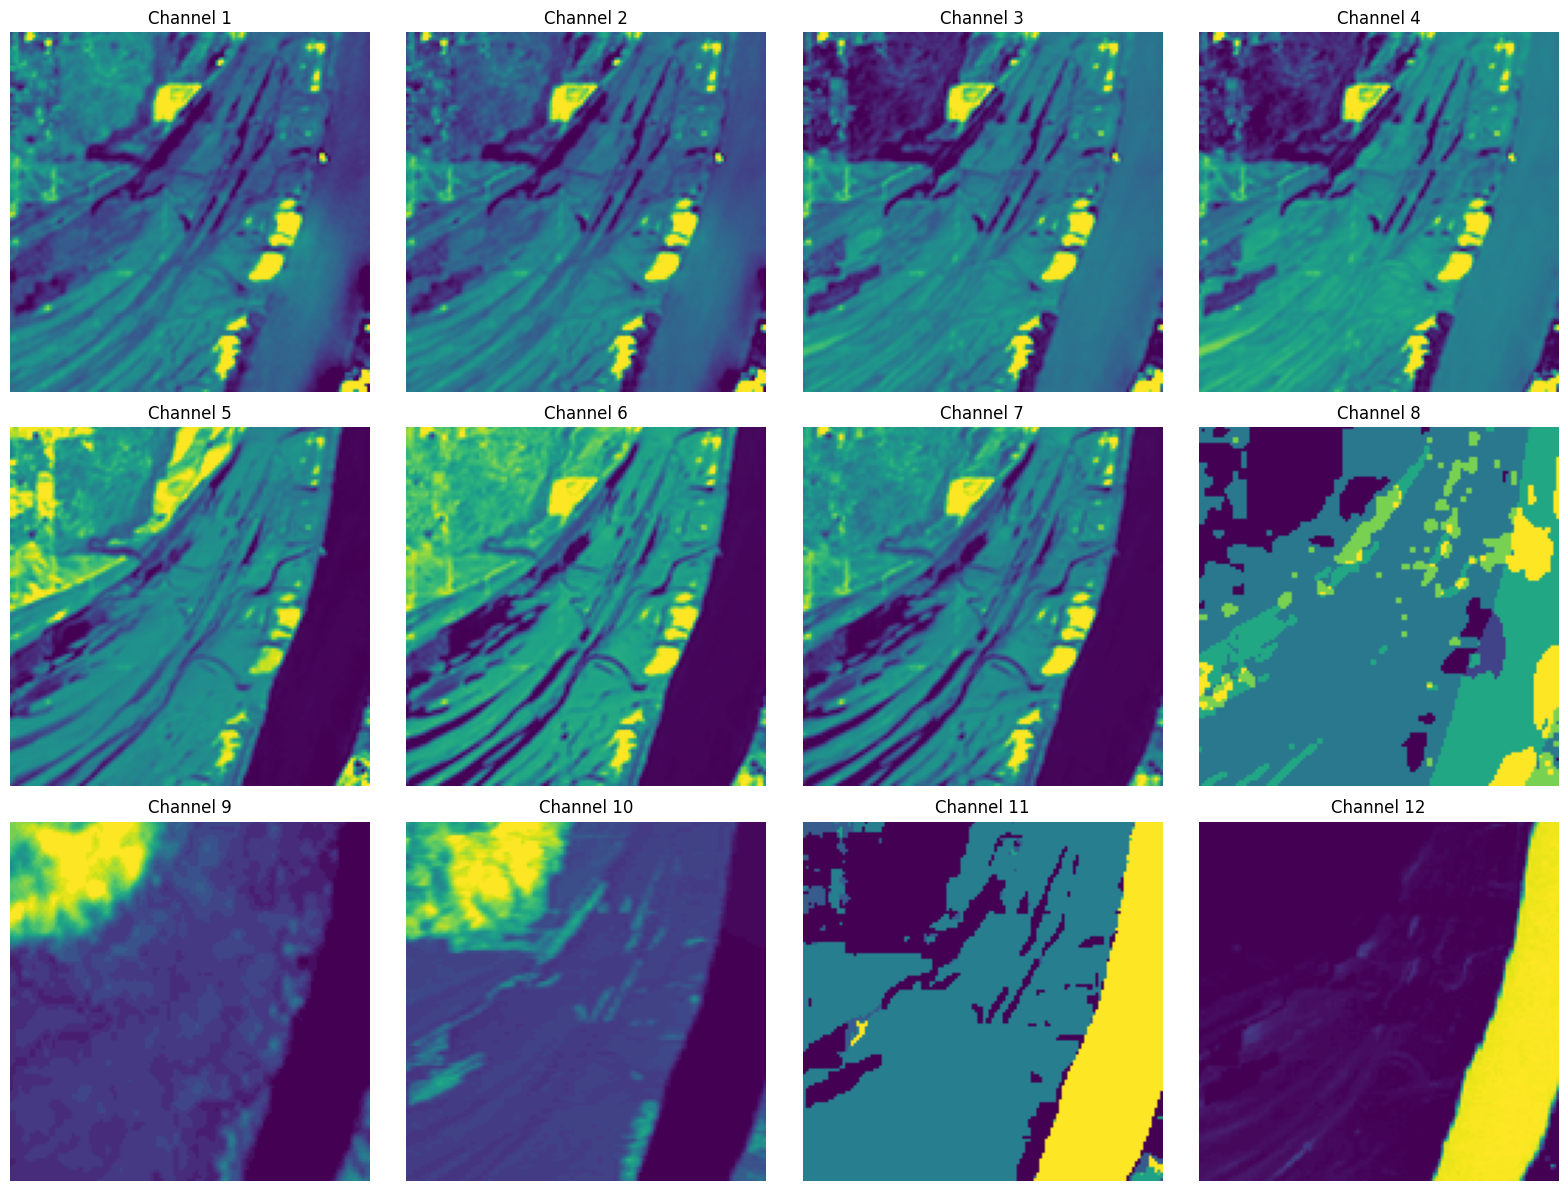

In [ ]:
sat_image = load_satellite_image(df['image_path'].iloc[160])
visualize_all_channels(sat_image)

In [ ]:
def load_raw_array(path):
    """Loads image or mask regardless of .tif or .png format."""
    if path.lower().endswith(('.tif', '.tiff')):
        return tiff.imread(path)
    else:
        return np.array(Image.open(path))

In [ ]:
import os
import numpy as np
import pandas as pd
import tifffile as tiff
from PIL import Image
import matplotlib.pyplot as plt




exploration_results = []

for idx, row in df.iterrows():
    img_path = row['image_path']
    label_path = row['label_path']

    
    img_arr = load_raw_array(img_path)
    label_arr = load_raw_array(label_path)

    # (12, H, W) or (H, W, 12)
    if img_arr.ndim == 3:
        if img_arr.shape[0] == 12:
            band_layout = "Channels First (C, H, W)"
            h, w = img_arr.shape[1], img_arr.shape[2]
            channels = img_arr.shape[0]
        elif img_arr.shape[2] == 12:
            band_layout = "Channels Last (H, W, C)"
            h, w = img_arr.shape[0], img_arr.shape[1]
            channels = img_arr.shape[2]
        else:
            band_layout = f"Custom 3D: {img_arr.shape}"
            h, w, channels = img_arr.shape[0], img_arr.shape[1], img_arr.shape[2]
    else:
        band_layout = "2D Grayscale"
        h, w = img_arr.shape[:2]
        channels = 1

#  Mask Class Distribution
    unique_mask_vals = np.unique(label_arr)

    #  mask to binary (0 = background/negative, 1 = target/positive)
    binary_mask = (label_arr > 0).astype(np.uint8)

    total_pixels = binary_mask.size
    pos_pixels = np.count_nonzero(binary_mask)
    neg_pixels = total_pixels - pos_pixels

    pos_percentage = (pos_pixels / total_pixels) * 100
    neg_percentage = (neg_pixels / total_pixels) * 100

    exploration_results.append({
        'file_id': row['file_id'],
        'img_shape': img_arr.shape,
        'img_dtype': img_arr.dtype,
        'band_layout': band_layout,
        'mask_shape': label_arr.shape,
        'mask_dtype': label_arr.dtype,
        'unique_mask_values': unique_mask_vals,
        'pos_pixels': pos_pixels,
        'neg_pixels': neg_pixels,
        'pos_class_%': round(pos_percentage, 2),
        'neg_class_%': round(neg_percentage, 2),
        'is_empty_mask': pos_pixels == 0
    })

eda_df = pd.DataFrame(exploration_results)


In [ ]:
file_path = '/content/drive/MyDrive/eda_data.csv'

df.to_csv(file_path, index=False)

In [ ]:
print("=== DATASET EXPLORATION SUMMARY ===")
print(f"Total Pairs Analyzed: {len(eda_df)}")
print(f"Band Layout Detected: {eda_df['band_layout'].value_counts().to_dict()}")
print(f"Image Data Types: {eda_df['img_dtype'].value_counts().to_dict()}")
print(f"Mask Data Types: {eda_df['mask_dtype'].value_counts().to_dict()}")
print(f"Unique Label Values across dataset: {np.unique(np.concatenate(eda_df['unique_mask_values'].values))}")
print(f"Empty Masks (Negative samples with 0 target pixels): {eda_df['is_empty_mask'].sum()} / {len(eda_df)}")

# Overall pixel balance across all images combined
total_all_pixels = eda_df['pos_pixels'].sum() + eda_df['neg_pixels'].sum()
overall_pos_pct = (eda_df['pos_pixels'].sum() / total_all_pixels) * 100
overall_neg_pct = (eda_df['neg_pixels'].sum() / total_all_pixels) * 100

print(f"\n=== OVERALL PIXEL DISTRIBUTION ===")
print(f"Positive (Target) Pixels: {overall_pos_pct:.2f}%")
print(f"Negative (Background) Pixels: {overall_neg_pct:.2f}%")

# Display per-file overview table
eda_df[['file_id', 'img_shape', 'band_layout', 'unique_mask_values', 'pos_class_%', 'neg_class_%', 'is_empty_mask']].head()

=== DATASET EXPLORATION SUMMARY ===
Total Pairs Analyzed: 306
Band Layout Detected: {'Channels Last (H, W, C)': 306}
Image Data Types: {dtype('int16'): 306}
Mask Data Types: {dtype('uint8'): 306}
Unique Label Values across dataset: [0 1]
Empty Masks (Negative samples with 0 target pixels): 45 / 306

=== OVERALL PIXEL DISTRIBUTION ===
Positive (Target) Pixels: 25.98%
Negative (Background) Pixels: 74.02%


,file_id,img_shape,band_layout,unique_mask_values,pos_class_%,neg_class_%,is_empty_mask
0,0,"(128, 128, 12)","Channels Last (H, W, C)","[0, 1]",11.70,88.30,False
1,1,"(128, 128, 12)","Channels Last (H, W, C)","[0, 1]",1.11,98.89,False
2,3,"(128, 128, 12)","Channels Last (H, W, C)","[0, 1]",5.32,94.68,False
3,8,"(128, 128, 12)","Channels Last (H, W, C)","[0, 1]",15.20,84.80,False
4,5,"(128, 128, 12)","Channels Last (H, W, C)",[0],0.00,100.00,True


In [ ]:

import argparse
import glob
import os

import numpy as np
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy import stats

def list_files(path):
    if os.path.isdir(path):
        files = []
        for ext in ("npy", "npz", "tif", "tiff"):
            files += glob.glob(os.path.join(path, f"*.{ext}"))
        return sorted(files)
    return [path]


def auc_from_ranks(x, y):
    """ROC-AUC via Mann-Whitney U (probability a random water pixel > random non-water pixel)."""
    ranks = stats.rankdata(x)
    y = y.astype(np.int64)
    n1 = int(y.sum())
    n0 = len(y) - n1
    return (ranks[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)



In [ ]:

def hist_overlap(a, b, bins=64):
    lo, hi = np.percentile(np.concatenate([a, b]), [0.5, 99.5])
    if hi <= lo:
        return 1.0
    ha, _ = np.histogram(a, bins=bins, range=(lo, hi))
    hb, _ = np.histogram(b, bins=bins, range=(lo, hi))
    ha = ha / max(ha.sum(), 1)
    hb = hb / max(hb.sum(), 1)
    return float(np.minimum(ha, hb).sum())





def plot_histograms(X, y, names, path, bins=60):
    C = X.shape[1]
    ncols = 4
    nrows = int(np.ceil(C / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for i in range(C):
        ax = axes[i]
        x = X[:, i]
        lo, hi = np.percentile(x, [0.5, 99.5])
        if hi <= lo:
            hi = lo + 1
        rng = (lo, hi)
        ax.hist(x[y == 0], bins=bins, range=rng, density=True, alpha=0.55, color="tab:orange", label="non-water")
        ax.hist(x[y == 1], bins=bins, range=rng, density=True, alpha=0.55, color="tab:blue", label="water")
        ax.set_title(names[i])
        ax.set_yticks([])
        if i == 0:
            ax.legend(fontsize=8)
    for j in range(C, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.savefig(path, dpi=130)
    plt.close()


def plot_ranking(rows, path):
    rows = sorted(rows, key=lambda r: r["separability"])
    names = [r["channel"] for r in rows]
    fig, ax = plt.subplots(figsize=(7, 0.4 * len(rows) + 1.5))
    colors = ["tab:blue" if r["auc"] > 0.5 else "tab:red" for r in rows]
    ax.barh(names, [r["separability"] for r in rows], color=colors)
    ax.set_xlabel("Separability = |AUC - 0.5| * 2   (blue: water brighter, red: water darker)")
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.savefig(path, dpi=130)
    plt.close()


AUC = 1.0: Perfect separation; every water pixel is brighter than all non-water pixels.

In [ ]:
import numpy as np
import tifffile as tiff
from PIL import Image


channel_names = [
    "Coastal aerosol",
    "B",
    "G",
    "R",
    "NIR",
    "SWIR1",
    "SWIR2",
    "QA Band",
    "Merit DEM",
    "Copernicus DEM",
    "Water occ prob" ,
    "ESA world cover map"
    
]

X_list =[]
y_list = []

for idx, (img_path, label_path) in enumerate(zip(df['image_path'], df['label_path'])):
    img = load_raw_array(img_path)    
    mask = load_raw_array(label_path)  #(H, W)

    # En (H, W, 12)
    if img.ndim == 3 and img.shape[0] == 12:
        img = np.transpose(img, (1, 2, 0))

    # Flatten
    pixels = img.reshape(-1, img.shape[-1])  #  (H*W, 12)
    labels = (mask.ravel() > 0).astype(np.int64)  #  (H*W,)


    X_list.append(pixels)
    y_list.append(labels)
    
X = np.vstack(X_list)        # (N_total_pixels, 12)
y = np.concatenate(y_list)   #  (N_total_pixels,)

rows = []
for i, name in enumerate(channel_names):
    x_channel = X[:, i]


    auc = auc_from_ranks(x_channel, y)
    separability = abs(auc - 0.5) * 2

    rows.append({
        "channel": name,
        "separability": float(separability),
        "auc": float(auc)
    })



In [ ]:
plot_ranking(rows, path="channel_ranking.png")

In [ ]:
df_rows = pd.DataFrame(rows)
file_path = '/content/drive/MyDrive/rows.csv'

df_rows.to_csv(file_path, index=False)

kept_channel = df_rows[df_rows["separability"] > 0.4]["channel"].unique().tolist()

print(kept_channel)



['NIR', 'SWIR1', 'SWIR2', 'Merit DEM', 'Copernicus DEM', 'ESA world cover map', 'Water occ prob']


In [ ]:
all_channels = df_rows["channel"].unique().tolist()

In [ ]:
import numpy as np

def process_channels(X, channels, all_channel_names=None, method="robust_min_max"):

    if len(channels) > 0 and isinstance(channels[0], str):
        if all_channel_names is None:
            raise ValueError("all_channel_names list must be provided when passing channel names as strings.")

        # names to num indices
        indices = [all_channel_names.index(name) for name in channels if name in all_channel_names]

    X_sub = X[:, indices].astype(np.float32)
    X_norm = np.zeros_like(X_sub)

#<<<<<<<<<<<<Avoided >>>>>>>>>>>>>>>>>>>

    # for c in range(X_sub.shape[1]):
    #     col = X_sub[:, c]
    #     if method == "robust_min_max":
    #         # 0.5 and 99.5 percentiles to clip  outliers
    #         lo, hi = np.percentile(col, [0.5, 99.5])
    #         if hi > lo:
    #             X_norm[:, c] = np.clip((col - lo) / (hi - lo), 0, 1)
    #         else:
    #             X_norm[:, c] = 0.0
        # elif method == "zscore":
        #     std = col.std()
        #     X_norm[:, c] = (col - col.mean()) / (std if std > 0 else 1.0)

    return X_norm

In [ ]:
X_normalized=process_channels(X, kept_channel,all_channels , method="robust_min_max")

In [ ]:
X_normalized

array([[0.08899722, 0.05316719, 0.02995616, ..., 0.11755547, 1.        ,
        0.        ],
       [0.08709466, 0.06251298, 0.03263517, ..., 0.11755547, 1.        ,
        0.        ],
       [0.15114729, 0.09781931, 0.05309303, ..., 0.11794472, 0.2857143 ,
        0.        ],
       ...,
       [0.67477226, 0.8562825 , 0.82415974, ..., 0.04165045, 0.42857143,
        0.        ],
       [0.6225577 , 0.82969886, 0.7761812 , ..., 0.04165045, 0.42857143,
        0.        ],
       [0.6143133 , 0.83489096, 0.783244  , ..., 0.04165045, 0.42857143,
        0.        ]], dtype=float32)

In [39]:
normalized_df = pd.DataFrame(X_normalized, columns=kept_channel)

print("DataFrame Shape:", normalized_df.shape)


DataFrame Shape: (5013504, 7)


In [40]:
normalized_df.to_csv('/content/drive/MyDrive/processed_pixels.csv', index=False)

In [47]:
normalized_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5013504 entries, 0 to 5013503
Data columns (total 7 columns):
 #   Column               Dtype  
---  ------               -----  
 0   NIR                  float32
 1   SWIR1                float32
 2   SWIR2                float32
 3   Merit DEM            float32
 4   Copernicus DEM       float32
 5   ESA world cover map  float32
 6   Water occ prob       float32
dtypes: float32(7)
memory usage: 133.9 MB


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#random
img_idx = 116


img_path = df['image_path'].iloc[img_idx]
raw_img = load_raw_array(img_path)  # Expected shape: (H, W, 12) or (12, H, W)

if raw_img.ndim == 3 and raw_img.shape[0] == 12:
    raw_img = np.transpose(raw_img, (1, 2, 0))

# integer indices of kept channels

kept_indices = [channel_names.index(name) for name in kept_channel if name in channel_names]

#  Extract and normalize only the kept channels for this single image
single_sat_image = process_channels(
    raw_img.reshape(-1, 12),
    channels=kept_channel,
    all_channel_names=all_channels,
    method="robust_min_max"
).reshape(raw_img.shape[0], raw_img.shape[1], len(kept_indices))


ncols = len(kept_indices)
fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 3))
axes = np.atleast_1d(axes)

for i in range(ncols):
    axes[i].imshow(single_sat_image[:, :, i], cmap='viridis')
    axes[i].set_title(kept_channel[i])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:

print("Shape to plot:", single_sat_image.shape)

if single_sat_image.shape[-1] == 0:
    print("Error: No channels were selected. Check `kept_channel` and `channel_names`.")
else:
    ncols = len(kept_indices)
    fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 3))
    axes = np.atleast_1d(axes)

    for i in range(ncols):
        axes[i].imshow(single_sat_image[:, :, i], cmap='viridis')
        axes[i].set_title(kept_channel[i])
        axes[i].axis('off')

    plt.savefig("debug_output.png")  
    plt.show(block=True)            

Shape to plot: (128, 128, 7)


In [50]:
print("Total rows in normalized_df:", len(normalized_df))
print("Total unique images in df['image_path']:", len(df))
print("Pixels per image stored in DataFrame:", len(normalized_df) // len(df))

Total rows in normalized_df: 5013504
Total unique images in df['image_path']: 306
Pixels per image stored in DataFrame: 16384


In [ ]:
normalized_df.to_csv('/content/drive/MyDrive/processed_pixels.csv', index=False)
